In [1]:
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from Bio.PDB import PDBParser, Superimposer
from Bio.PDB.Polypeptide import is_aa

# ver useful doumentation link is https://biopython.org/docs/latest/Tutorial/chapter_pdb.html
def get_ca_atoms(structure):
    """
    Extracts Alpha Carbon (CA) atoms from the first model of a structure.
    """
    atoms = []
    # We iterate over the first model (model[0])
    # In NMR for example there are often many models each havign diffrent conformation of the same protein. we ignroe this and just use the  first one as we also geneally will only have one from crystalization 
    for chain in structure[0]:
        for residue in chain:
            # For standart maino acids id[0] will be ' '
            # documentaion https://biopython.org/docs/dev/Tutorial/chapter_pdb.html seach hetero-field 
            # Skip heteroatoms (water, ligands)
            if residue.id[0] != ' ':
                continue

            # based on the documentation:
            # if there is a calcilum atom it will also be called CA in the pdb but with diffrent spaceing. pdb usually have calculum atom mas "CA.." and Alpha carbons as ".CA." 
            # if there is not conflict (so only calclium or only alpha carbons) then they will only called CA otherwise the sapcing is kept. wither way we can get thefull name with spacing of the atom using atom.fullname
            # for now i just do it in the standd way expecting just one CA but do osme exception if weid things happen. it they do might wannt just go over the full name of the atoms and look for ".CA."
            if residue.has_id("CA"):
                if not is_aa(residue):
                    raise Exception("has CA but not an AA; strange but possible tbh can just remove this check later if it makign issues")
                atoms.append(residue['CA'])
            else:
                if residue.has_id(" CA ") or residue.has_id(" CA"):
                    raise Exception("There is both calcilum and carbon atom")
    return atoms

def calculate_rmsd_atoms(ref_atoms, sample_atoms):
    """
    Superimposes ref_atoms onto sample_atoms and calculates RMSD.
    """
    # Check for residue mismatch
    if len(ref_atoms) != len(sample_atoms):
        raise Exception(f"Atom count mismatch ({len(ref_atoms)} vs {len(sample_atoms)}). RMSD may be invalid without sequence alignment.")
    
    # Initialize Superimposer
    # assuming that there is the same number of atoms in both stucture. if there is not and we need to align we need to use CEAligner  instead of this
    # The algorithm used by Superimposer comes from Golub & Van Loan [Golub1989] and makes use of singular value decomposition (this is implemented in the general Bio.SVDSuperimposer module).
    super_imposer = Superimposer()
    super_imposer.set_atoms(ref_atoms, sample_atoms)
    
    ### a possible alternative to ths algotitehm si to use In addition to using the Superimposer object, you can also choose to use the QCPSuperimposer object, which is faster than the standard Superimposer. The algorithm for the QCPSuperimposer comes from Theobald [Theobald2005] and rapidly calculates the minimum RMSD by using the quaternion characteristic polynomial (QCP).
    
    # Return the RMSD
    return super_imposer.rms

In [2]:
from Bio.SeqUtils import seq1

def get_CA_atoms_of_fuzed_c6b6_partial_T25_34(fuzed_structure, G_fuzed_pos = [38, 77, 116, 155, 194], expected_seq_for_sanity_check=None):
    """
    G_fuzed_pos: there should be 6 chains of 38 AA each, fuzed with G (aka GLY) whcih are expcted in these indexes
    """
    # make sure that fuzed stuct has just one model 
    assert len(fuzed_structure) == 1

    # make sure that is 1 chain
    all_chains = list(fuzed_structure.get_chains()) 
    assert len(all_chains ) == 1

    fuzed_chain = all_chains[0]

    all_residues = list(fuzed_chain.get_residues())

    # sanity check that these are all these indecies indeed are GLY
    for G_pos in G_fuzed_pos:
        assert all_residues[G_pos].resname == "GLY"

    # sanity check 2, that the rest of the sequence is actually following the expcted seqeunce 

    ## select the CA atoms
    atoms = []

    # We iterate over the first model (model[0])
    # In NMR for example there are often many models each havign diffrent conformation of the same protein. we ignroe this and just use the  first one as we also geneally will only have one from crystalization 
    for i, residue in enumerate(all_residues):
        
        # verify that the sequence if what we expect, this is a sanity check that the pdb file order is follwoign the same order of amino acids that we expect
        if expected_seq_for_sanity_check:
            assert seq1(residue.resname) == expected_seq_for_sanity_check[i] 

        # skip the G that is added to fuze the chains
        if i in G_fuzed_pos:
            continue

        # For standart maino acids id[0] will be ' '
        # documentaion https://biopython.org/docs/dev/Tutorial/chapter_pdb.html seach hetero-field 
        # Skip heteroatoms (water, ligands)
        if residue.id[0] != ' ':
            raise Exception("We do not expect non AA residues in this pdb")

        # based on the documentation:
        # if there is a calcilum atom it will also be called CA in the pdb but with diffrent spaceing. pdb usually have calculum atom mas "CA.." and Alpha carbons as ".CA." 
        # if there is not conflict (so only calclium or only alpha carbons) then they will only called CA otherwise the sapcing is kept. wither way we can get thefull name with spacing of the atom using atom.fullname
        # for now i just do it in the standd way expecting just one CA but do osme exception if weid things happen. it they do might wannt just go over the full name of the atoms and look for ".CA."
        if residue.has_id("CA"):
            if not is_aa(residue):
                raise Exception("has CA but not an AA; strange but possible tbh can just remove this check later if it makign issues")
            atoms.append(residue['CA'])
        else:
            if residue.has_id(" CA ") or residue.has_id(" CA"):
                raise Exception("There is both calcilum and carbon atom")

    return atoms


In [3]:
def read_pdbs_in_folder(folder):
    parser = PDBParser(QUIET=True)
    # Load Predicted Structures
    pred_files = [f for f in os.listdir(folder) if f.endswith(".pdb")]
    pred_structs = []
    
    print(f"Found {len(pred_files)} predicted structures.")
    for f in pred_files:
        path = os.path.join(folder, f)
        struct = parser.get_structure(f, path)
        pred_structs.append((f, struct))

    return pred_structs

In [ ]:
# e.g.
data_dict = {"predicted_pdb_file": None, # the file name of the predicted folded file
             "rmsd": None, # rmsd of the alpha carbons, against the input pdb that MPNN had used.
             "predicted_struct_avg_plddt": None, # the avergae plddt of the predicted fold
             "is_well_folded" : None, # an derived property from the rmsd and predicted_struct_avg_plddt. we use these on certain threshld to cdermined if the seqeunce was considered sucussefully folded
             "seq" : None, # the amino acid seqeunce that mpnn predicted
             "__original_fa_file_MPNN_global_score": None, # the mpnn score that this seqeunce got on the roginal file from bence, this is just usign one decoding order.
             "score_using_mean_probs": None # the MPNN score that thesequnce would get if we are using the averge of the probably dist of the maino acids over many doecing order here instead  
              }

In [5]:
# Copied from protein_mpnn_run.py
def parse_fasta(filename,limit=-1, omit=[]):
    header = []
    sequence = []
    lines = open(filename, "r")
    for line in lines:
        line = line.rstrip()
        if line[0] == ">":
            if len(header) == limit:
                break
            header.append(line[1:])
            sequence.append([])
        else:
            if omit:
                line = [item for item in line if item not in omit]
                line = ''.join(line)
            line = ''.join(line)
            sequence[-1].append(line)
    lines.close()
    sequence = [''.join(seq) for seq in sequence]
    return np.array(header), np.array(sequence)

In [6]:
import re
def exarct_key_from_fa_name(line, key):
    pattern = rf"\b{key}=([-+]?[\d.]+)"
    match = re.search(pattern, line)

    return match.group(1)

In [7]:
def read_mpnn_fasta(MPNN_fa_path):
    """
    MPNN_fa_path path for the mpnn fa file with all the predicted seqeunes
    skip_first the first line in the fa file is not containign a preicted sequnece but it is of the seqeuncein the pdb file and we are not intrested in that here
    """
    fasta_names, fasta_seqs = parse_fasta(MPNN_fa_path)
    
    all_seqs = []
        
    for i in range(len(fasta_names)):

        fasta_name = str(fasta_names[i])
        seq = str(fasta_seqs[i])
        global_score = float(exarct_key_from_fa_name(line=fasta_name, key="global_score"))

        all_seqs.append({"fasta_name": fasta_name, 
                       "seq": seq,
                        "__original_fa_file_MPNN_global_score": global_score})

    return all_seqs

In [8]:
# --- CONFIGURATION ---
partial_struct_filename = "c6b6_partial_T25_34"
# path for the fa file that mpnn created with predicted sequecnes
MPNN_fa_path = f"/data/leuven/368/vsc36835/thesis/hpc_scratch_link/Bence Files/For_bence/MPNN-for-c6-1/seqs/{partial_struct_filename}.fa"
mpnn_input_pdb_path = f"/data/leuven/368/vsc36835/thesis/hpc_scratch_link/Bence Files/For_bence/MPNN-for-c6-1/inputs/{partial_struct_filename}.pdb"  # Replace with your true PDB file
predicted_dir = f"/data/leuven/368/vsc36835/thesis/hpc_scratch_link/Bence Files/c6b6/{partial_struct_filename}_esmfold"        # Folder containing predicted PDBs
# the folder that has the npz files that hold the mean probablity distribtuion over many samples
npz_files_folder = f"/data/leuven/368/vsc36835/thesis/MPNN_distribution_proeprties_check/bence files/{partial_struct_filename}_input_pdb"
# ---------------------


In [9]:
from Bio.PDB import PDBParser, PPBuilder
def get_seq_from_pdb(pdb_path):
    # 1. Initialize the parser and the builder
    parser = PDBParser(QUIET=True)
    ppb = PPBuilder()

    # 2. Load the structure
    structure = parser.get_structure("my_protein", pdb_path)

    # 3. Extract sequences from all chains
    all_sequences = []
    for pp in ppb.build_peptides(structure):
        sequence = pp.get_sequence()
        all_sequences.append(str(sequence))

    return "".join(all_sequences)

In [10]:
import os 
def get_predicted_folded_pdb_path(fa_name, pdbs_dir):
    """
    returns the path for the predicted pdb given the fa_name, we also provide the pdb_dir that it would search in 
    """
    
    fa_name_esacped = fa_name.replace(',', '')
    fa_name_esacped = fa_name_esacped.replace(' ', '_')

    expected_path = os.path.join(pdbs_dir, f"{fa_name_esacped}_esmfold.pdb")

    if not os.path.exists(expected_path):
        raise Exception("Expected to find pdb at " + expected_path )
        
    return expected_path

In [11]:
def verify_seq_and_predicted_pdb_are_the_same(mpnn_seq, pdb_path, expected_G_positions):
    """
    verify that the predicted (esmfolded) pdb file is really of sequence mpnn_seq
    we expect that there will be extra G residues inn the pdb file that are connecting the chains 
    """
    pdb_seq = get_seq_from_pdb(pdb_path)

    # '/' in mpnn_seq represent a new chain, these positions should have a 'G' residue instead on the pdb seq
    # first we want to get the position that there is chain break, and make sure it is what we expect
    new_chain_indexes = []
    for i, letter in enumerate(mpnn_seq):
        if letter == '/':
            new_chain_indexes.append(i)

    # use set to ignore the order
    assert set(new_chain_indexes) == set(expected_G_positions)

    # make sure the rest of the sequence is the same
    assert mpnn_seq.replace("/", "G") == pdb_seq

    return True

In [72]:
### add mpnn to path so i can load functio nfro mthere
import sys
from pathlib import Path
import torch

# 1. Get the absolute path to the directory containing 'utils.py'
# .parent.parent moves up from 'scripts/' to 'project/', then we go into 'tools/'
path_to_utils = "/data/leuven/368/vsc36835/thesis/MPNN_4/ProteinMPNN"

# 2. Add that path to sys.path
sys.path.append(str(path_to_utils))

# 3. Now you can import normally
from protein_mpnn_utils import _scores, _S_to_seq


def get_mpnn_score_from_non_log_scale_proba(S, avg_probablity_dist_NOT_log_scaled, mask):
    """
    S : numpy array. the seqeunce to score
    avg_probablity_dist_NOT_log_scaled : numpy array. the probablity dist per residue shape (len, 21) this needs to be not in log sacled 
    mask : numpy array. the mask to use
    """
    assert np.isclose(avg_probablity_dist_NOT_log_scaled[0].sum(), 1), "This should sum up to 1. maybe the probablily distritbion is in log scaled"

    log_proba_dist = np.log(avg_probablity_dist_NOT_log_scaled)
    

    # convert to tensors 
    log_proba_dist = torch.from_numpy(log_proba_dist)
    S = torch.from_numpy(S)
    mask = torch.from_numpy(mask)

    return _scores(S, log_proba_dist, mask).item()



In [13]:
def get_predicted_pdb_rmsd_and_plddt_exlcuding_fuzed_G(predicted_pdb_path, ref_pdb_structure, G_fuzed_pos, expected_seq_for_sanity_check=None):
    """
    predicted_pdb_path: the predicted pdb file 
    ref_pdb_structure: the input file for MPNN, here used as "ground truth" to caclaulte rmsd agaist
    G_fuzed_pos: the positions on the pdbfile that have extra G residues. We will ignore these in the rmsd and plddt calculations
    expected_seq_for_sanity_check: the expected seq in the predicted_pdb file, essetnally the sanity check is that the order of the pdb file is the same as the sequence. The expected seqeunce here is with '/' to seperate the chains, the function is conevrting these '/' to the G residue so that we can omapre it to predicted pdb.
    """
    parser = PDBParser(QUIET=True)

    assert os.path.exists(predicted_pdb_path)

    # the "ground true" is the name that we give the structure in the file, 
    ref_struct = parser.get_structure("rmsd ref", mpnn_input_pdb_path)

    # Load Predicted Structure   
    pred_structs = parser.get_structure("pred stucture", predicted_pdb_path)

    # get the CA atoms of the ref
    ref_atoms = get_ca_atoms(ref_struct)

    expected_seq_replaced_G = None
    if expected_seq_for_sanity_check:
        expected_seq_replaced_G = expected_seq_for_sanity_check.replace("/", "G")

    # getting the CA atoms of the predicted pdb
    predicted_pdb_atoms = get_CA_atoms_of_fuzed_c6b6_partial_T25_34(pred_structs, G_fuzed_pos=G_fuzed_pos, expected_seq_for_sanity_check=expected_seq_replaced_G)

    plddt_scores = [atom.get_bfactor() for atom in predicted_pdb_atoms]
    avg_plddt = sum(plddt_scores) / len(plddt_scores)

    rmsd = calculate_rmsd_atoms(ref_atoms, predicted_pdb_atoms)

    return {'rmsd': rmsd, 'predicted_struct_avg_plddt': avg_plddt}


In [14]:
def is_confidence_fold(rmsd, avg_plddt, min_plddt=80, max_rmsd=2.0):
    """
    return if we consider the pdb well folded
    we use the threshold provided so to be considered well folded the rmsd needs to be lower than max_rmsd and plddt higher than min_plddt 
    """
    return {"is_confidence_fold" : (rmsd < max_rmsd) and (avg_plddt > min_plddt)}

In [15]:
def load_npz_file(npz_path):
    npz_data = np.load(npz_path)

    probs_list_stacked = npz_data["probs_list_stacked"]
    S = npz_data["S"]
    mask = npz_data["mask"]
    seq = "".join(npz_data["seq"].tolist())
    global_scores = npz_data["global_scores"]

    return {"avg_probbablity_dist": probs_list_stacked,
    "S": S,
    "mask": mask,
    "seq": seq,
    "global_scores": global_scores}

In [16]:
def find_npz_path(fasta_name, struct_name, npz_files_folder):
    import glob
    # this is not super elegant but cause i use the fa index in the file name, and i dont want this functino to nede the fa file i use * instead. this is not unsafe howeevr since we return the seq from the npz file and will confirm that it is what we expect
    expected_path_pattern = os.path.join(npz_files_folder, f"fullscores_{struct_name}_*_{glob.escape(fasta_name)}.npz")
    expected_path = glob.glob(expected_path_pattern)
    assert len(expected_path) == 1
    expected_path = expected_path[0]
    assert os.path.exists(expected_path)
    return expected_path

def find_and_load_npz_file(fasta_name, struct_name, npz_files_folder):
    return load_npz_file(find_npz_path(fasta_name, struct_name, npz_files_folder))

In [73]:
all_pred_seq_features = [] 
all_pred_seq_features = read_mpnn_fasta(MPNN_fa_path)

# this is for c6b6_partial_T25_34, for now we only use this stcuture
expected_G_fuzed_pos = [38, 77, 116, 155, 194]

for pred_seq in all_pred_seq_features:
    # Find correposneding predicted pdb
    predicted_pdb_path = get_predicted_folded_pdb_path(pred_seq["fasta_name"], predicted_dir)

    # verify that seq and pdb match
    if not verify_seq_and_predicted_pdb_are_the_same(pred_seq["seq"], predicted_pdb_path, expected_G_positions=expected_G_fuzed_pos):
        raise Exception("seq and pdb are not the same")

    pred_seq["predicted_pdb_path"] = predicted_pdb_path

    # calculate the rmsd and plddt
    rmsd_plddt_dict = get_predicted_pdb_rmsd_and_plddt_exlcuding_fuzed_G(predicted_pdb_path=pred_seq["predicted_pdb_path"], 
                                                        ref_pdb_structure=mpnn_input_pdb_path, 
                                                        G_fuzed_pos=expected_G_fuzed_pos, 
                                                        expected_seq_for_sanity_check=pred_seq["seq"])
    pred_seq.update(rmsd_plddt_dict)

    # check if the predicted pdb is havign a high condeifnece in the folding
    is_confidence_fold_dict = is_confidence_fold(rmsd=pred_seq["rmsd"], avg_plddt=pred_seq["predicted_struct_avg_plddt"])

    pred_seq.update(is_confidence_fold_dict)

    npz_data = find_and_load_npz_file(pred_seq["fasta_name"], struct_name=partial_struct_filename, npz_files_folder=npz_files_folder)

    # make sure we loaded the right npz, seq should be the same but the npz does not have the / signs that indicate chaisn spererting 
    assert npz_data["seq"] == pred_seq["seq"].replace("/","")

    # essentally add everything except seq cause we alrady have it 
    npz_keys_to_add = ['avg_probbablity_dist', 'S', 'mask', 'global_scores']
    pred_seq.update({k: npz_data[k] for k in npz_keys_to_add if k in npz_data})

    # The mean global score of many differnet deocding orders, just dereived property from the global_scores to make analysis easier
    mean_global_score = np.mean(pred_seq["global_scores"])
    pred_seq.update({"mean_global_score": mean_global_score})


    # global score using the avg_probbablity_dist
    global_score_using_avg_probbablity_dist = get_mpnn_score_from_non_log_scale_proba(pred_seq["S"], 
                                                                pred_seq["avg_probbablity_dist"],
                                                                pred_seq["mask"])

    pred_seq.update({"global_score_using_avg_probbablity_dist": global_score_using_avg_probbablity_dist})


In [74]:
keys_for_df = ['fasta_name', 'seq', '__original_fa_file_MPNN_global_score', 'predicted_pdb_path', 'rmsd', 'predicted_struct_avg_plddt', 'is_confidence_fold', 'mean_global_score', 'global_score_using_avg_probbablity_dist']

#### tempoerary fix, ignoring the first line usign [1:] since iti s the pdb sequnce and it has very high score 
all_pred_seq_features_df = pd.DataFrame(all_pred_seq_features[1:], columns=keys_for_df)
all_pred_seq_features_df = all_pred_seq_features_df.sort_values(by='rmsd').reset_index(drop=True)


In [23]:
# all_pred_seq_features_df

## descriptive stats


STATISTICAL SUMMARY
Total Predictions: 1000

[Accuracy (RMSD)]
  Best (Lowest):   T=0.2, sample=431, score=0.5895, global_score=0.5895, seq_recovery=0.1842 (0.516 Å)
  Mean RMSD:       3.717 Å

[Confidence (pLDDT)]
  Highest pLDDT:   T=0.2, sample=315, score=0.5920, global_score=0.5920, seq_recovery=0.2368 (91.62)
  Mean pLDDT:      71.91
  Pearson R:       -0.852
  P-value:         4.075e-282 (Significant)


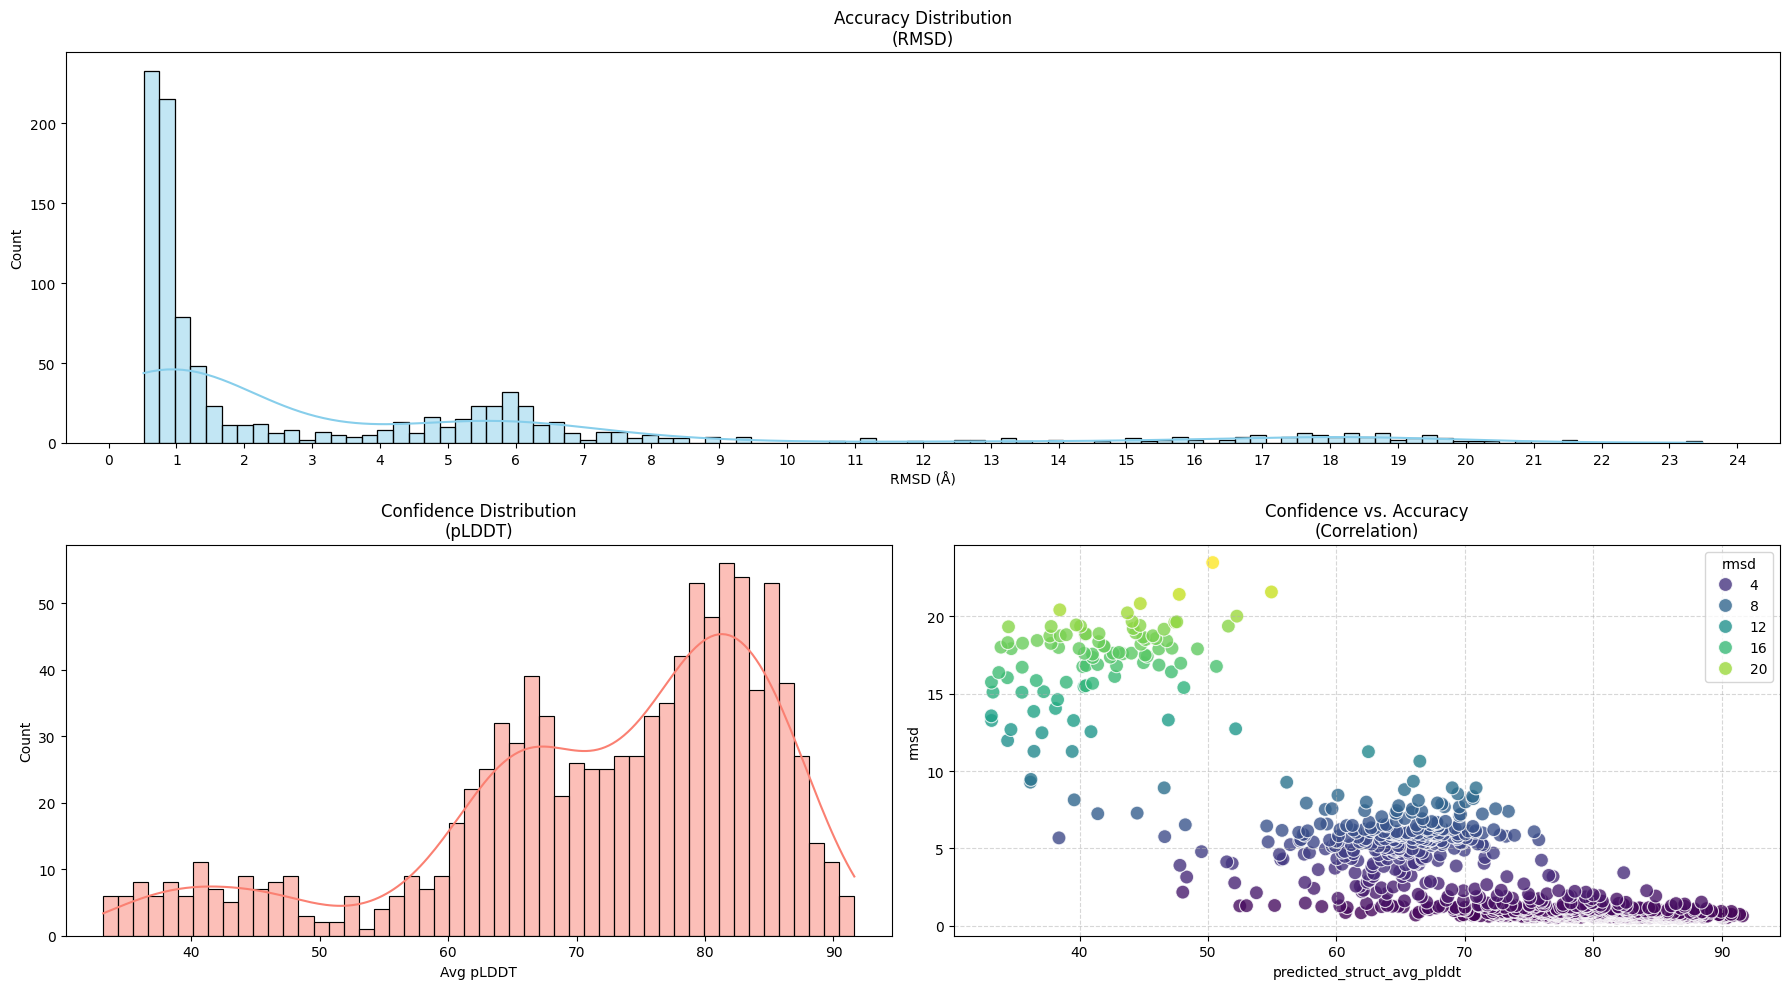

In [24]:
import seaborn as sns
from scipy.stats import pearsonr

print("\n" + "="*40)
print("STATISTICAL SUMMARY")
print("="*40)

print(f"Total Predictions: {len(all_pred_seq_features_df)}")

# Accuracy stats
print(f"\n[Accuracy (RMSD)]")
print(f"  Best (Lowest):   {all_pred_seq_features_df.iloc[0]['fasta_name']} ({all_pred_seq_features_df.iloc[0]['rmsd']:.3f} Å)")
print(f"  Mean RMSD:       {all_pred_seq_features_df['rmsd'].mean():.3f} Å")

# Confidence stats
print(f"\n[Confidence (pLDDT)]")
best_plddt_row = all_pred_seq_features_df.loc[all_pred_seq_features_df['predicted_struct_avg_plddt'].idxmax()]
print(f"  Highest pLDDT:   {best_plddt_row['fasta_name']} ({best_plddt_row['predicted_struct_avg_plddt']:.2f})")
print(f"  Mean pLDDT:      {all_pred_seq_features_df['predicted_struct_avg_plddt'].mean():.2f}")

# pearsonr returns (correlation_coefficient, p_value)
corr_coeff, p_value = pearsonr(all_pred_seq_features_df['predicted_struct_avg_plddt'], all_pred_seq_features_df['rmsd'])
print(f"  Pearson R:       {corr_coeff:.3f}")
print(f"  P-value:         {p_value:.3e} " + ("(Significant)" if p_value < 0.05 else "(Not Significant)"))

# 3. Visualization
plt.figure(figsize=(18, 10))

# Plot 1: RMSD Distribution
plt.subplot(2, 2, (1, 2))
sns.histplot(all_pred_seq_features_df['rmsd'], kde=True, color='skyblue', bins=100)
plt.title('Accuracy Distribution\n(RMSD)')
plt.xlabel('RMSD (Å)')
plt.locator_params(axis='x', nbins=50)


# Plot 2: pLDDT Distribution
plt.subplot(2, 2, 3)
sns.histplot(all_pred_seq_features_df['predicted_struct_avg_plddt'], kde=True, color='salmon', bins=50)
plt.title('Confidence Distribution\n(pLDDT)')
plt.xlabel('Avg pLDDT')

# Plot 3: Correlation (Guaranteed Aligned)
plt.subplot(2, 2, 4)
# We use results_df as the source, ensuring X and Y are paired by index
sns.scatterplot(data=all_pred_seq_features_df, x='predicted_struct_avg_plddt', y='rmsd', 
                hue='rmsd', palette='viridis', s=100, alpha=0.8)
plt.title('Confidence vs. Accuracy\n(Correlation)')
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

Mean global score vs the orgonal global score with just a single deocding order

/tmp/ipykernel_3800696/1225926311.py:1: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(data=all_pred_seq_features_df, x='__original_fa_file_MPNN_global_score', y='mean_global_score',


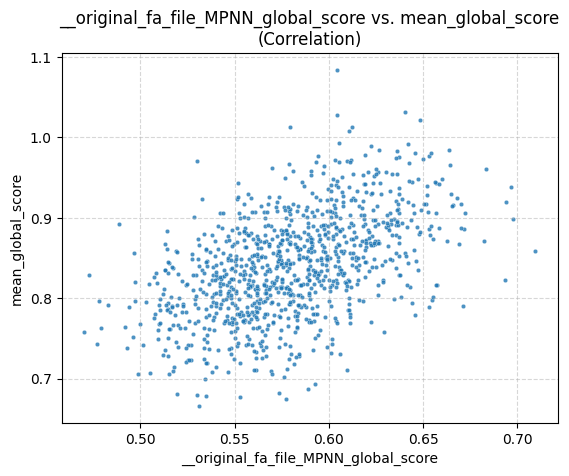

In [75]:
sns.scatterplot(data=all_pred_seq_features_df, x='__original_fa_file_MPNN_global_score', y='mean_global_score', 
                palette='viridis', s=10, alpha=0.8)
plt.title('__original_fa_file_MPNN_global_score vs. mean_global_score\n(Correlation)')
plt.grid(True, linestyle='--', alpha=0.5)

/tmp/ipykernel_3800696/2310072881.py:1: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(data=all_pred_seq_features_df, x='__original_fa_file_MPNN_global_score', y='global_score_using_avg_probbablity_dist',


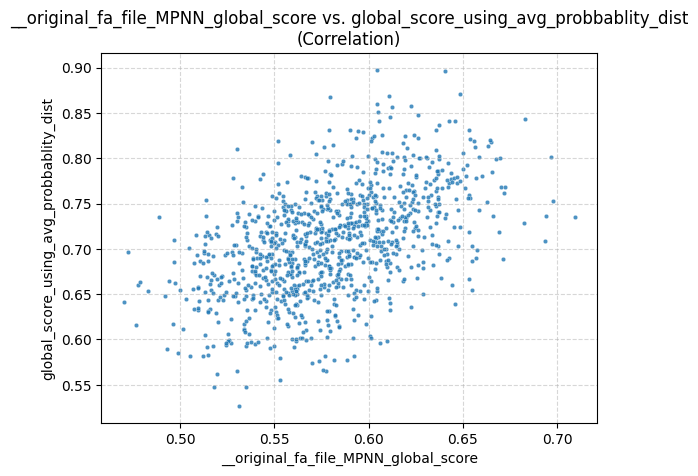

In [26]:

sns.scatterplot(data=all_pred_seq_features_df, x='__original_fa_file_MPNN_global_score', y='global_score_using_avg_probbablity_dist', 
                palette='viridis', s=10, alpha=0.8)
plt.title('__original_fa_file_MPNN_global_score vs. global_score_using_avg_probbablity_dist\n(Correlation)')
plt.grid(True, linestyle='--', alpha=0.5)



/tmp/ipykernel_3800696/1605039524.py:1: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(data=all_pred_seq_features_df, x='mean_global_score', y='global_score_using_avg_probbablity_dist',


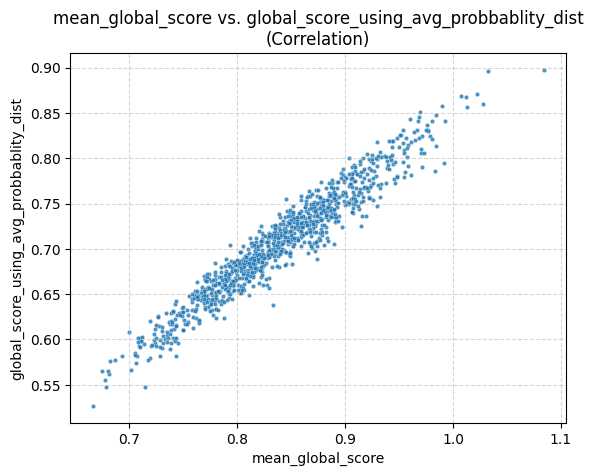

In [48]:
sns.scatterplot(data=all_pred_seq_features_df, x='mean_global_score', y='global_score_using_avg_probbablity_dist', 
                palette='viridis', s=10, alpha=0.8)
plt.title('mean_global_score vs. global_score_using_avg_probbablity_dist\n(Correlation)')
plt.grid(True, linestyle='--', alpha=0.5)

Is confidence fold and mpnn score from the original file
  Point-Biserial R: -0.256
  P-value:          1.919e-16 (Significant)


/tmp/ipykernel_3622554/3568931780.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=all_pred_seq_features_df, x='is_confidence_fold', y='__original_fa_file_MPNN_global_score', palette='Set2')


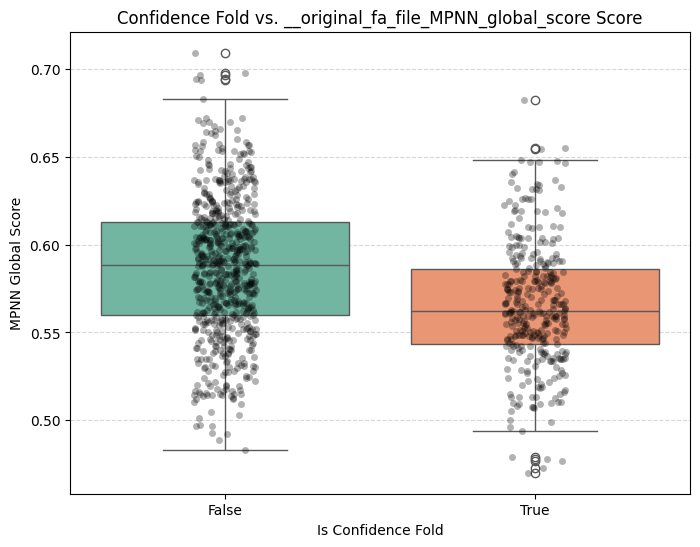

In [25]:
from scipy.stats import pointbiserialr
import matplotlib.pyplot as plt
import seaborn as sns

# pointbiserialr is used for correlation between a binary variable and a continuous variable
corr_coeff, p_value = pointbiserialr(all_pred_seq_features_df['is_confidence_fold'], all_pred_seq_features_df['__original_fa_file_MPNN_global_score'])
print(f"Is confidence fold and mpnn score from the original file")
print(f"  Point-Biserial R: {corr_coeff:.3f}")
print(f"  P-value:          {p_value:.3e} " + ("(Significant)" if p_value < 0.05 else "(Not Significant)"))

# A boxplot or violin plot is better for binary vs continuous
plt.figure(figsize=(8, 6))
sns.boxplot(data=all_pred_seq_features_df, x='is_confidence_fold', y='__original_fa_file_MPNN_global_score', palette='Set2')
sns.stripplot(data=all_pred_seq_features_df, x='is_confidence_fold', y='__original_fa_file_MPNN_global_score', color='black', alpha=0.3)

plt.title('Confidence Fold vs. __original_fa_file_MPNN_global_score Score')
plt.xlabel('Is Confidence Fold')
plt.ylabel('MPNN Global Score')
plt.grid(True, linestyle='--', alpha=0.5, axis='y')
plt.show()

Is confidence fold and mpnn score from the original file
  Point-Biserial R: -0.377
  P-value:          4.637e-35 (Significant)


/tmp/ipykernel_3622554/4276787149.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=all_pred_seq_features_df, x='is_confidence_fold', y='mean_global_score', palette='Set2')


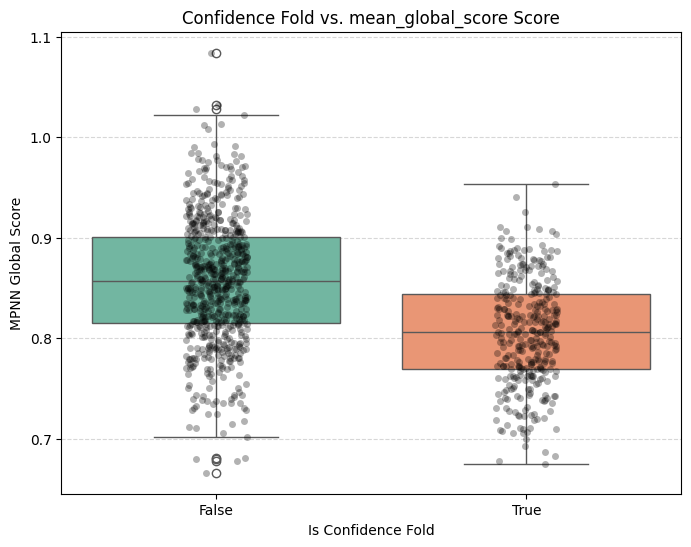

In [26]:
from scipy.stats import pointbiserialr
import matplotlib.pyplot as plt
import seaborn as sns

# pointbiserialr is used for correlation between a binary variable and a continuous variable
corr_coeff, p_value = pointbiserialr(all_pred_seq_features_df['is_confidence_fold'], all_pred_seq_features_df['mean_global_score'])
print(f"Is confidence fold and mpnn score from the original file")
print(f"  Point-Biserial R: {corr_coeff:.3f}")
print(f"  P-value:          {p_value:.3e} " + ("(Significant)" if p_value < 0.05 else "(Not Significant)"))

# A boxplot or violin plot is better for binary vs continuous
plt.figure(figsize=(8, 6))
sns.boxplot(data=all_pred_seq_features_df, x='is_confidence_fold', y='mean_global_score', palette='Set2')
sns.stripplot(data=all_pred_seq_features_df, x='is_confidence_fold', y='mean_global_score', color='black', alpha=0.3)

plt.title('Confidence Fold vs. mean_global_score Score')
plt.xlabel('Is Confidence Fold')
plt.ylabel('MPNN Global Score')
plt.grid(True, linestyle='--', alpha=0.5, axis='y')
plt.show()

Is confidence fold and mpnn score from the original file
  Point-Biserial R: -0.318
  P-value:          5.714e-25 (Significant)


/tmp/ipykernel_3800696/1417774118.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=all_pred_seq_features_df, x='is_confidence_fold', y='global_score_using_avg_probbablity_dist', palette='Set2')


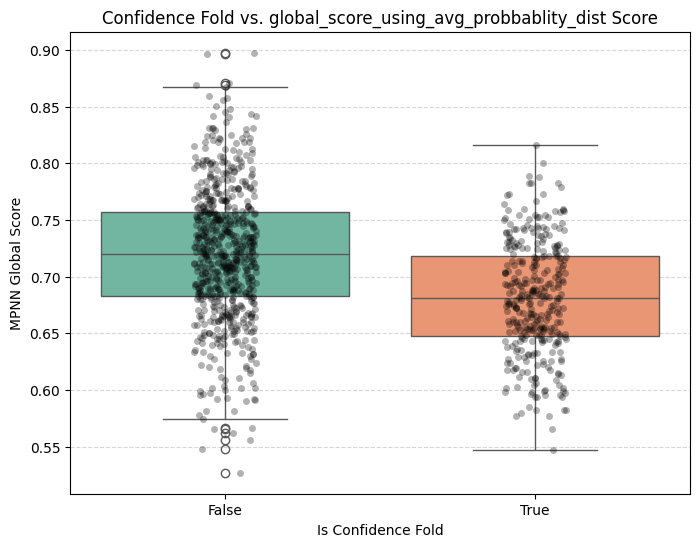

In [76]:
from scipy.stats import pointbiserialr
import matplotlib.pyplot as plt
import seaborn as sns

# pointbiserialr is used for correlation between a binary variable and a continuous variable
corr_coeff, p_value = pointbiserialr(all_pred_seq_features_df['is_confidence_fold'], all_pred_seq_features_df['global_score_using_avg_probbablity_dist'])
print(f"Is confidence fold and mpnn score from the original file")
print(f"  Point-Biserial R: {corr_coeff:.3f}")
print(f"  P-value:          {p_value:.3e} " + ("(Significant)" if p_value < 0.05 else "(Not Significant)"))

# A boxplot or violin plot is better for binary vs continuous
plt.figure(figsize=(8, 6))
sns.boxplot(data=all_pred_seq_features_df, x='is_confidence_fold', y='global_score_using_avg_probbablity_dist', palette='Set2')
sns.stripplot(data=all_pred_seq_features_df, x='is_confidence_fold', y='global_score_using_avg_probbablity_dist', color='black', alpha=0.3)

plt.title('Confidence Fold vs. global_score_using_avg_probbablity_dist Score')
plt.xlabel('Is Confidence Fold')
plt.ylabel('MPNN Global Score')
plt.grid(True, linestyle='--', alpha=0.5, axis='y')
plt.show()

### There is a stronger correlation (-0.377 vs -0.256) between the mean_global_score (global score over many decoding orders) and the __original_fa_file_MPNN_global_score (the single global_score that we got when the mpnn original sample)

the score using the average_proba_dist is getting -0.318

The single score is biasesd since in the code they use the same decoding order for the sample() and the scoring, espically with high temperature we are biasing the choies to be the ones that will give the best mpnn score for that deocding order, so actully the score that we get in a single run is quite unrepresentative. 

In [ ]:
def convert_back_to_prob(score, seq_len):
    return np.exp(-score*seq_len)

logisitc regression 

In [77]:
all_pred_seq_features_df.keys()

Index(['fasta_name', 'seq', '__original_fa_file_MPNN_global_score',
       'predicted_pdb_path', 'rmsd', 'predicted_struct_avg_plddt',
       'is_confidence_fold', 'mean_global_score',
       'global_score_using_avg_probbablity_dist'],
      dtype='str')

--- Logistic Regression Results ---
Coefficient: -4.9280
Intercept:   10.6801
Accuracy:    0.7040


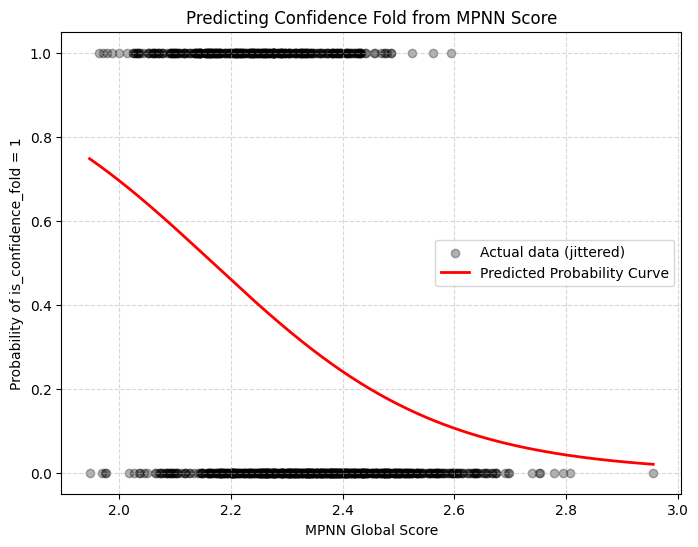

In [78]:
from sklearn.linear_model import LogisticRegression
import numpy as np
import matplotlib.pyplot as plt

# Prepare the data
# X needs to be a 2D array for scikit-learn
# X = all_pred_seq_features_df['__original_fa_file_MPNN_global_score'].astype(float).values.reshape(-1, 1)

# X = np.exp(all_pred_seq_features_df['__original_fa_file_MPNN_global_score'].astype(float)).values.reshape(-1, 1)

X = np.exp(all_pred_seq_features_df['mean_global_score'].astype(float)).values.reshape(-1, 1)

# y needs to be an integer (0 or 1)
y = all_pred_seq_features_df['is_confidence_fold'].astype(int).values

# 2. Initialize and fit the Logistic Regression model
clf = LogisticRegression()
clf.fit(X, y)

# 3. Print the model coefficients and accuracy
print("--- Logistic Regression Results ---")
print(f"Coefficient: {clf.coef_[0][0]:.4f}")
print(f"Intercept:   {clf.intercept_[0]:.4f}")
print(f"Accuracy:    {clf.score(X, y):.4f}")

# 4. Visualization
plt.figure(figsize=(8, 6))

# Scatter plot of original datapoints (1 = True, 0 = False)
plt.scatter(X, y, color='black', alpha=0.3, label='Actual data (jittered)')

# Generate a range of values to plot the smooth probability curve
x_vals = np.linspace(X.min(), X.max(), 300).reshape(-1, 1)
# predict_proba returns [prob_class_0, prob_class_1] - we want class 1
y_probs = clf.predict_proba(x_vals)[:, 1]

plt.plot(x_vals, y_probs, color='red', linewidth=2, label='Predicted Probability Curve')

plt.title('Predicting Confidence Fold from MPNN Score')
plt.xlabel('MPNN Global Score')
plt.ylabel('Probability of is_confidence_fold = 1')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

In [79]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
from sklearn.metrics import log_loss

In [80]:
from sklearn.metrics import roc_curve, auc, RocCurveDisplay, average_precision_score, log_loss
from sklearn.utils.multiclass import unique_labels

def fit_and_eval(X, y, train_idx, test_idx):
    return_dict = {}

    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression())
    ])

    pipeline.fit(X_train, y_train)

    model = pipeline.named_steps['clf']

    # get coefficients
    # model.intercept_ is a 1D array, model.coef_ is a 2D array
    ## we only take model.coef_[0] and not model.coef_ cause we only have one class (binary classification) if tehre are multiple a coefficiant set will be fitted for each class
    return_dict["intercept_and_coefficiants"] = np.concatenate([model.intercept_, model.coef_[0]])


    # eval
    y_pred_test = pipeline.predict(X_test)

    # Confustion Matrix
    return_dict["cm"] = confusion_matrix(y_test, y_pred_test)
    return_dict["cm_display_labels"] =  unique_labels(y_test, y_pred_test)

    # Accuracy
    return_dict["test_accuracy"]  = accuracy_score(y_test, y_pred_test)


    # ROC
    y_pred_test_proba = pipeline.predict_proba(X_test)
    # get only the probably of class 1 (well_folded=1)
    y_pred_test_proba_class_1 = y_pred_test_proba[:,1]
    # Compute ROC curve and area the curve
    fpr, tpr, thresholds = roc_curve(y_test, y_pred_test_proba_class_1)
    roc_auc = auc(fpr, tpr)
    return_dict["fpr"] = fpr
    return_dict["tpr"] = tpr 
    return_dict["thresholds"] = thresholds
    return_dict["roc_auc"] = roc_auc

    # log_loss_test
    return_dict["log_loss_test"] = log_loss(y_test, y_pred_test_proba)
    
    # average_precision_score_test
    return_dict["average_precision_score_test"] = average_precision_score(y_test, y_pred_test_proba_class_1)

    return return_dict

In [81]:
def plot_roc_curve(fpr, tpr, thresholds):
    roc_auc = auc(fpr, tpr)

    display = RocCurveDisplay(
            fpr=fpr, 
            tpr=tpr, 
            roc_auc=roc_auc
            )
        
    # Plot it
    fig, ax = plt.subplots(figsize=(7, 5))
    display.plot(ax=ax, color='darkorange', lw=2)

    # Add the chance line
    ax.plot([0, 1], [0, 1], linestyle="--", color="navy", label="Chance (AUC = 0.50)")

    ax.set_title(f"Manual ROC Curve")
    ax.legend(loc="lower right")
    plt.grid(True, alpha=0.3)
    plt.show()


In [82]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

def plot_confusion_matrix(cm, display_labels, title="", ax=None):
    """
    Plots a Confusion Matrix directly from a 2D numpy array/variable.
    """

    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 6))
        show_plot = True
    else:
        show_plot = False

    # 1. Initialize the display object with the matrix
    # 'cm' must be a 2D array, e.g., [[TN, FP], [FN, TP]]
    disp = ConfusionMatrixDisplay(confusion_matrix=cm.astype(int), 
                                  display_labels=display_labels)
    
    # 2. Plot it

    disp.plot(ax=ax, cmap='Blues', values_format='d') # 'd' ensures integers are shown
    
    ax.set_title(title)
    if show_plot:
        plt.show()

In [83]:
def plot_sum_cm_over_folds(all_folds_results, ax=None):
    all_cms = []
    display_labels = []

    for fold_results in all_folds_results:
        all_cms.append(fold_results["cm"])
        display_labels.append(fold_results["cm_display_labels"])

    # sanity check - make sure display labels order is allways the same
    assert False not in [np.array_equal(display_labels[0], d) for d in display_labels]

    # we SUM them and not averge
    sum_cms = np.sum(np.array(all_cms), axis=0)

    plot_confusion_matrix(sum_cms, display_labels[0], "Sumed confustion matrix over folds", ax=ax)


In [84]:
import matplotlib.pyplot as plt
from sklearn.metrics import RocCurveDisplay, auc

def plot_overlaid_roc(all_fpr, all_tpr, all_thresholds, ax=None):
    """
    Plots individual ROC curves for each fold on a single graph.
    """
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 6))
        show_plot = True
    else:
        show_plot = False

    # 1. Loop through the pre-calculated metrics for each fold
    for i, (fpr, tpr) in enumerate(zip(all_fpr, all_tpr)):
        roc_auc = auc(fpr, tpr)
        
        # 2. Use the 'direct' display method we discussed
        display = RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc, 
                                  name=f"Fold {i+1}")
        
        # 3. Plot on the SAME axis (ax=ax)
        # We use a lower alpha (transparency) so the lines don't get too messy
        display.plot(ax=ax, curve_kwargs={'alpha': 0.6, 'lw': 1})

    # 4. Add the "Chance" line
    ax.plot([0, 1], [0, 1], linestyle="--", color="red", label="Chance (AUC = 0.50)")

    ax.set_title("Overlaid ROC Curves across K-Folds")
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.legend(loc="lower right", fontsize='small', ncol=2) # ncol=2 keeps the legend compact
    plt.grid(True, alpha=0.3)

    if show_plot:
        plt.show()


In [85]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def plot_coefficient_boxplots(list_of_coefs, feature_names, ax=None):
    """
    Creates a boxplot for each coefficient and intercept across folds.
    """

    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 6))
        show_plot = True
    else:
        show_plot = False

    # 1. Convert list of lists to a DataFrame
    # list_of_coefs shape: (n_folds, n_features)
    df = pd.DataFrame(list_of_coefs, columns=feature_names)
    
    # 2. Reshape for plotting (Melt into "Parameter" and "Weight")
    df_melted = df.melt(var_name='Parameter', value_name='Weight')

    # 3. Draw the Boxplot (shows the distribution)
    sns.boxplot(x='Parameter', y='Weight', data=df_melted, 
                palette="Set3", hue="Parameter", width=0.5, showfliers=False, ax=ax)

    # 4. Draw the Swarmplot (shows the individual fold points)
    # This ensures points don't overlap too much
    sns.swarmplot(x='Parameter', y='Weight', data=df_melted, 
                  color=".25", size=6, edgecolor="white", linewidth=1, ax=ax)

    # 5. Add the 'Zero' reference line
    plt.axhline(0, color='red', linestyle='--', alpha=0.7, label='Zero Effect')

    ax.set_title("Coefficient Stability: Boxplot of Fold Variations")
    ax.set_ylabel("Standardized Coefficient (Log-Odds)")
    ax.set_xlabel("Model Component")
    ax.grid(True, axis='y', alpha=0.3)
    if show_plot:
        plt.tight_layout()
        plt.show()

In [86]:
def cross_val_split(X, y, n_splits=5):
    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    # return list of fold for each fold tuple train_idx, test_idx 
    return list(cv.split(X, y))

In [98]:
def plot_results_acorss_folds(all_folds_results):

    fig, axes = plt.subplots(1, 3, figsize=(20, 6))

    ### plot CM over folds
    plot_sum_cm_over_folds(all_folds_results, ax=axes[0])


    ### plot ROC over folds
    all_fpr = []
    all_tpr = []
    all_thresholds = []

    for fold_result in all_folds_results:
        all_fpr.append(fold_result["fpr"])
        all_tpr.append(fold_result["tpr"])
        all_thresholds.append(fold_result["thresholds"])

    plot_overlaid_roc(all_fpr, all_tpr, all_thresholds, ax=axes[1])


    ### plot coefficients over folds
    all_intercept_and_coefficiants = []

    for fold_result in all_folds_results:
        all_intercept_and_coefficiants.append(fold_result["intercept_and_coefficiants"])

    plot_coefficient_boxplots(all_intercept_and_coefficiants, ["intercept", "MPNN_score", "asd"], ax=axes[2])


    # avg AUC
    all_auc = []
    for fold_result in all_folds_results:
        all_auc.append(fold_result["roc_auc"])
    avg_auc = np.array(all_auc).mean()

    print(f"avg AUC {avg_auc}")

    # avg log_loss_test
    all_logloss = []
    for fold_result in all_folds_results:
        all_logloss.append(fold_result["log_loss_test"])
    avg_logloss = np.array(all_logloss).mean()

    print(f"avglogloss {avg_logloss}")

    # avg average_precision_score_test
    all_AP = []
    for fold_result in all_folds_results:
        all_AP.append(fold_result["average_precision_score_test"])
    avg_AP = np.array(all_AP).mean()

    print(f"avg_AP {avg_AP}")



avg AUC 0.732462801588535
avglogloss 0.5641791738526984
avg_AP 0.5576203448197922


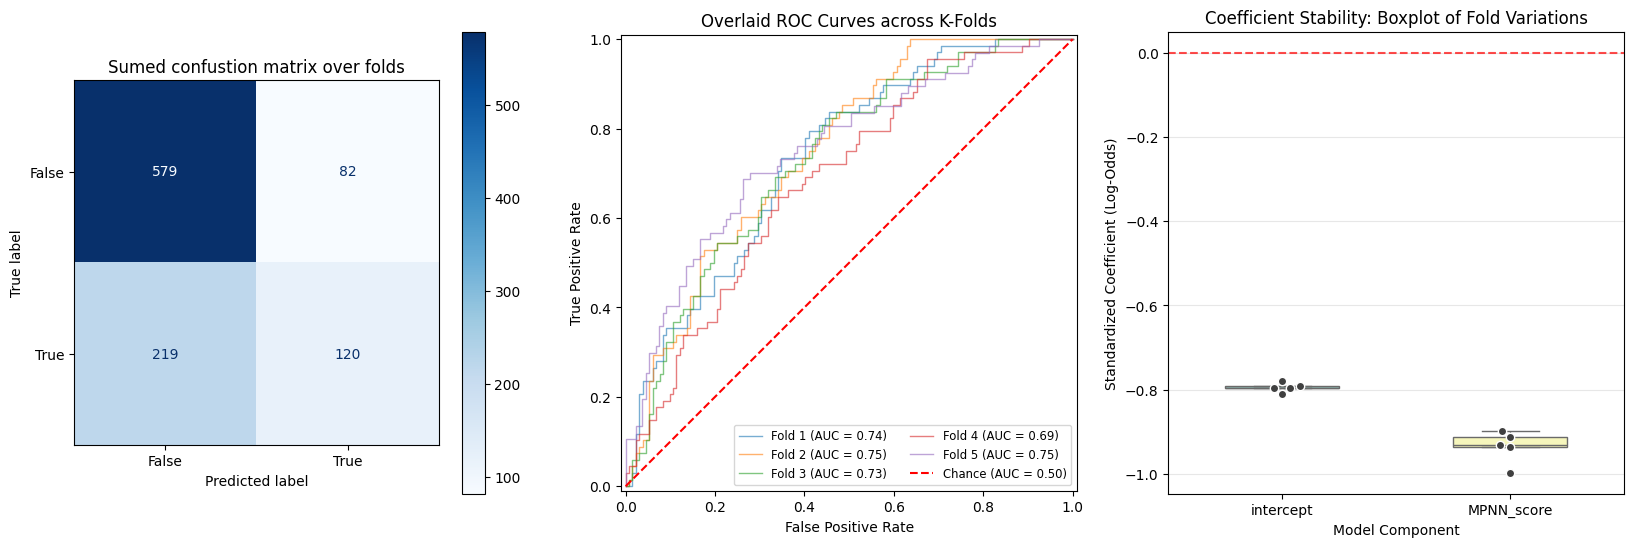

In [ ]:
all_X = all_pred_seq_features_df[['mean_global_score']].to_numpy()
all_y = all_pred_seq_features_df['is_confidence_fold'].to_numpy()

folds_idx = cross_val_split(all_X, all_y) 

all_folds_results = []
for fold_num in range(len(folds_idx)):
    all_folds_results.append(fit_and_eval(all_X, all_y, train_idx=folds_idx[fold_num][0], test_idx=folds_idx[fold_num][1]))

plot_results(all_folds_results)


In [90]:
all_pred_seq_features_df.keys()

Index(['fasta_name', 'seq', '__original_fa_file_MPNN_global_score',
       'predicted_pdb_path', 'rmsd', 'predicted_struct_avg_plddt',
       'is_confidence_fold', 'mean_global_score',
       'global_score_using_avg_probbablity_dist'],
      dtype='str')

ValueError: 2 columns passed, passed data had 3 columns

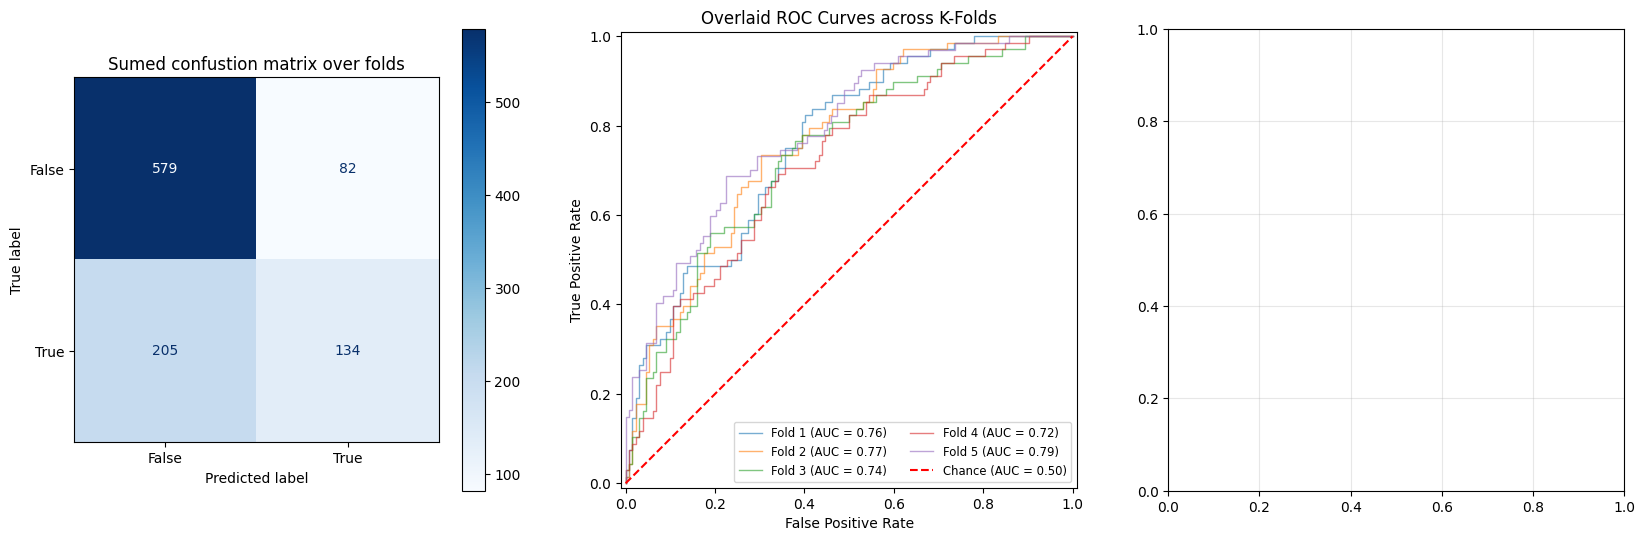

In [99]:
all_X = all_pred_seq_features_df[['global_score_using_avg_probbablity_dist', 'mean_global_score']].to_numpy()
all_y = all_pred_seq_features_df['is_confidence_fold'].to_numpy()

folds_idx = cross_val_split(all_X, all_y) 

all_folds_results = []
for fold_num in range(len(folds_idx)):
    all_folds_results.append(fit_and_eval(all_X, all_y, train_idx=folds_idx[fold_num][0], test_idx=folds_idx[fold_num][1]))

plot_results(all_folds_results)
